
=== Cross-simulation Evaluation Train=SIMBA → Test=TNG ===
     param      R2    RMSE     MAE  Pearson_r  Spearman_rho
0  Omega_m  0.9459  0.0269  0.0209     0.9754        0.9821
1   sigma8  0.6957  0.0637  0.0513     0.8562        0.8697


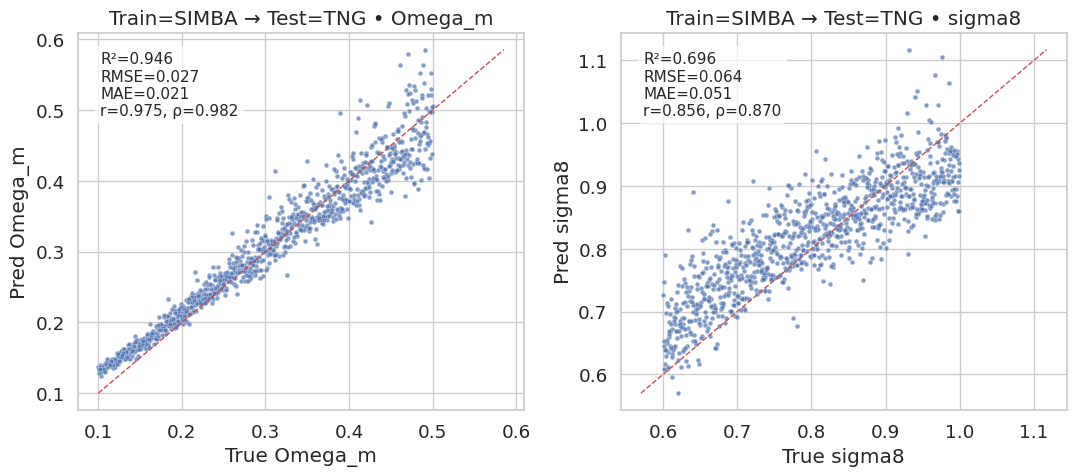


=== Cross-simulation Evaluation Train=TNG → Test=SIMBA ===
     param      R2    RMSE     MAE  Pearson_r  Spearman_rho
0  Omega_m  0.7932  0.0525  0.0360     0.9688        0.9773
1   sigma8  0.5021  0.0815  0.0639     0.7619        0.7905


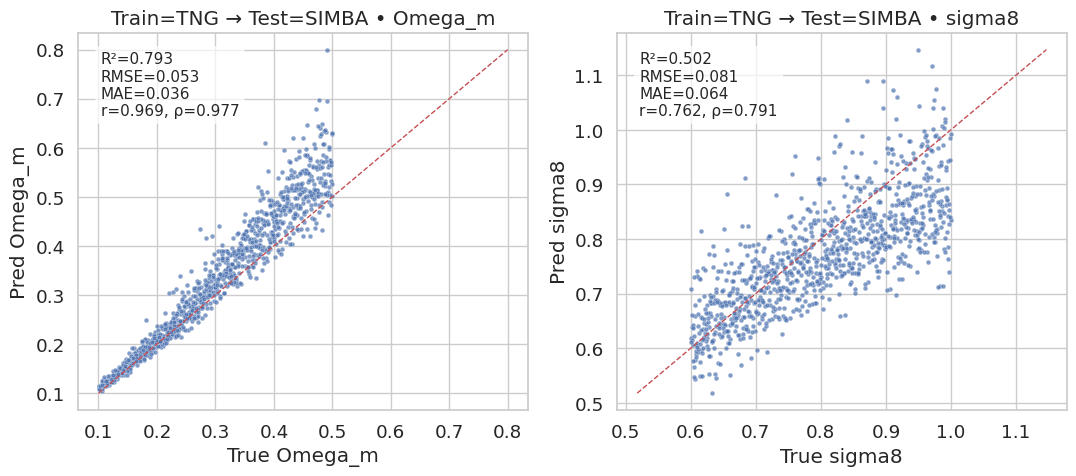

In [1]:
# =====================
# Cross-simulation Evaluation Script
# =====================
import os, glob
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

from unet.model import UNetEncoderRegressor

sns.set(style="whitegrid", font_scale=1.2)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------
# Utility functions
# ---------------------
def get_latest_file(base_dir: str, filename: str) -> str:
    subdirs = glob.glob(os.path.join(base_dir, "20*"))
    if not subdirs:
        raise FileNotFoundError(f"No subdirectories found in {base_dir}")
    latest_dir = max(subdirs, key=os.path.getmtime)
    return os.path.join(latest_dir, filename)

def compute_metrics(df, param_cols, pred_cols):
    metrics = []
    for tcol, pcol in zip(param_cols, pred_cols):
        y_true, y_pred = df[tcol].values, df[pcol].values
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_true - y_pred))
        r2 = r2_score(y_true, y_pred)
        pear = np.corrcoef(y_true, y_pred)[0,1]
        spear = pd.Series(y_true).corr(pd.Series(y_pred), method="spearman")
        metrics.append(dict(param=tcol.replace("true_",""),
                            R2=r2, RMSE=rmse, MAE=mae,
                            Pearson_r=pear, Spearman_rho=spear))
    return pd.DataFrame(metrics)

# ---------------------
# Cross-sim evaluation core
# ---------------------
def cross_eval(model_dir, test_img_path, test_param_path, tag=""):
    # 1) 데이터 로드
    X = np.load(test_img_path).astype(np.float32)
    y = np.loadtxt(test_param_path).astype(np.float32)

    # shape 보정 (CAMELS multifield 포맷 기준)
    if y.ndim == 2 and y.shape[1] == X.shape[0]:
        y = y.T
    y = y[:, :2]  # (Omega_m, sigma8)

    if X.ndim == 3 and X.shape[0] % 15 == 0:
        n_sims = X.shape[0] // 15
        X = X.reshape(n_sims, 15, X.shape[1], X.shape[2])

    # 2) 모델 로드
    model_path = get_latest_file(model_dir, "best_model.pt")
    model = UNetEncoderRegressor(in_channels=15, out_dim=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # 3) 예측
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), 32):
            batch = torch.tensor(X[i:i+32], dtype=torch.float32).to(device)
            out = model(batch).cpu().numpy()
            preds.append(out)
    preds = np.vstack(preds)

    # 4) 결과 DataFrame
    df = pd.DataFrame({
        "true_Omega_m": y[:,0],
        "pred_Omega_m": preds[:,0],
        "true_sigma8":  y[:,1],
        "pred_sigma8":  preds[:,1],
    })
    param_cols = [c for c in df.columns if c.startswith("true_")]
    pred_cols  = [c for c in df.columns if c.startswith("pred_")]
    param_names = [c.replace("true_", "") for c in param_cols]

    # 5) 메트릭
    metrics = compute_metrics(df, param_cols, pred_cols)

    print(f"\n=== Cross-simulation Evaluation {tag} ===")
    print(metrics.round(4))

    # 6) 시각화: scatter
    n_params = len(param_names)
    fig, axes = plt.subplots(1, n_params, figsize=(5.5*n_params, 5))
    if n_params == 1: axes=[axes]
    for ax, pname, tcol, pcol in zip(axes, param_names, param_cols, pred_cols):
        sns.scatterplot(x=df[tcol], y=df[pcol], s=12, alpha=0.7, ax=ax)
        lims=[min(df[tcol].min(),df[pcol].min()), max(df[tcol].max(),df[pcol].max())]
        ax.plot(lims, lims, "r--", lw=1)
        m = metrics[metrics["param"]==pname].iloc[0]
        txt=(f"R²={m['R2']:.3f}\nRMSE={m['RMSE']:.3f}\nMAE={m['MAE']:.3f}\n"
             f"r={m['Pearson_r']:.3f}, ρ={m['Spearman_rho']:.3f}")
        ax.text(0.05,0.95,txt,transform=ax.transAxes,va="top",ha="left",
                fontsize=11,bbox=dict(boxstyle="round,pad=0.3",facecolor="white",alpha=0.7))
        ax.set_xlabel(f"True {pname}")
        ax.set_ylabel(f"Pred {pname}")
        ax.set_title(f"{tag} • {pname}")
    plt.tight_layout(); plt.show()

    return df, metrics

# ---------------------
# 실행 예시
# ---------------------
# Case A: Train=SIMBA, Test=TNG
simba_dir = "./unet/runs/case_1_SIMBA_Mtot_A"
tng_imgs = "./data/CAMELS_multifield/Maps_Mtot_IllustrisTNG_LH_z=0.00.npy"
tng_params = "./data/CAMELS_multifield/params_LH_IllustrisTNG.txt"

df1, m1 = cross_eval(simba_dir, tng_imgs, tng_params, tag="Train=SIMBA → Test=TNG")

# Case B: Train=TNG, Test=SIMBA
tng_dir = "./unet/runs/case_4_TNG_Mtot_A"
simba_imgs = "./data/CAMELS_multifield/Maps_Mtot_SIMBA_LH_z=0.00.npy"
simba_params = "./data/CAMELS_multifield/params_LH_SIMBA.txt"

df2, m2 = cross_eval(tng_dir, simba_imgs, simba_params, tag="Train=TNG → Test=SIMBA")


In [12]:
# ============================================
# Cross-Simulation Evaluation + 2x2 Plot Script
#   - Models: case_1_SIMBA_Mtot_A, case_4_TNG_Mtot_A
#   - Metrics: R2, RMSE, MAE, Pearson r, Spearman ρ,
#              MAPE (%) and signed Relative Bias (%)
#   - Plots: per-parameter 2x2 grids (in-sim vs cross, SIMBA vs TNG)
# ============================================
import os, glob, time
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

from unet.model import UNetEncoderRegressor

sns.set(style="whitegrid", font_scale=1.2)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------
# Configuration
# ---------------------
SIMBA_RUN_DIR = "./unet/runs/case_1_SIMBA_Mtot_A"
TNG_RUN_DIR   = "./unet/runs/case_4_TNG_Mtot_A"

# in-sim prediction CSV(혹은 디렉토리) 경로
INSIM_SIMBA_PRED_PATH = "./unet/predictions/case_1_SIMBA_Mtot_A"
INSIM_TNG_PRED_PATH   = "./unet/predictions/case_4_TNG_Mtot_A"

# cross-sim 테스트용 데이터 경로
TNG_IMGS_NPY   = "./data/CAMELS_multifield/Maps_Mtot_IllustrisTNG_LH_z=0.00.npy"
TNG_PARAMS_TXT = "./data/CAMELS_multifield/params_LH_IllustrisTNG.txt"
SIMBA_IMGS_NPY = "./data/CAMELS_multifield/Maps_Mtot_SIMBA_LH_z=0.00.npy"
SIMBA_PARAMS_TXT = "./data/CAMELS_multifield/params_LH_SIMBA.txt"

SAVE_DIR = "./eval_results"
os.makedirs(SAVE_DIR, exist_ok=True)
TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# ---------------------
# Utilities
# ---------------------
def get_latest_file(base_dir: str, filename: str) -> str:
    """base_dir 하위(YYYY* 형태)에서 가장 최신 폴더의 filename 경로를 반환."""
    subdirs = [d for d in glob.glob(os.path.join(base_dir, "20*")) if os.path.isdir(d)]
    if not subdirs:
        raise FileNotFoundError(f"No timestamp subdirectories found in {base_dir}")
    latest_dir = max(subdirs, key=os.path.getmtime)
    path = os.path.join(latest_dir, filename)
    if not os.path.isfile(path):
        raise FileNotFoundError(f"File not found: {path}")
    return path
import re
import pandas as pd
import os, glob

def load_prediction_csv(path_or_dir: str) -> pd.DataFrame:
    """
    In-sim prediction CSV 로더 (견고 버전)
    - 디렉토리 입력 시: 타임스탬프(20*) 하위의 predictions.csv를 우선 사용.
    - 컬럼 표준화:
        true_sigma_8 / pred_sigma_8  → true_sigma8 / pred_sigma8
        대소문자·공백·언더스코어 변형 허용.
    - 최종 요구 컬럼:
        true_Omega_m, pred_Omega_m, true_sigma8, pred_sigma8
    """
    # 1) CSV 경로 선택
    if os.path.isdir(path_or_dir):
        cand_dirs = sorted(
            [d for d in glob.glob(os.path.join(path_or_dir, "20*")) if os.path.isdir(d)],
            key=os.path.getmtime, reverse=True
        )
        csv_path = None
        for d in cand_dirs + [path_or_dir]:
            p1 = glob.glob(os.path.join(d, "**/predictions.csv"), recursive=True)
            if p1:
                csv_path = sorted(p1, key=os.path.getmtime)[-1]
                break
        if csv_path is None:
            csvs = glob.glob(os.path.join(path_or_dir, "**/*.csv"), recursive=True)
            if not csvs:
                raise FileNotFoundError(f"No CSVs under: {path_or_dir}")
            csv_path = max(csvs, key=os.path.getmtime)
    else:
        csv_path = path_or_dir
        if not os.path.isfile(csv_path):
            raise FileNotFoundError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)

    # 2) 컬럼명 표준화
    rename_map = {}
    for c in df.columns:
        c_new = c.strip()

        # sigma_8, sigma 8, Sigma_8, SIGMA8 -> sigma8  (※ \g<1>8 사용!)
        c_new = re.sub(r"(sigma)[\s_]*8", r"\g<1>8", c_new, flags=re.IGNORECASE)

        # true/pred + omega m 표준화
        c_new = re.sub(r"^(true)[\s_]*omega[\s_]*m$",  r"true_Omega_m", c_new, flags=re.IGNORECASE)
        c_new = re.sub(r"^(pred)[\s_]*omega[\s_]*m$",  r"pred_Omega_m", c_new, flags=re.IGNORECASE)

        # true/pred + sigma8 표준화
        c_new = re.sub(r"^(true)[\s_]*sigma8$",        r"true_sigma8",  c_new, flags=re.IGNORECASE)
        c_new = re.sub(r"^(pred)[\s_]*sigma8$",        r"pred_sigma8",  c_new, flags=re.IGNORECASE)

        rename_map[c] = c_new

    df = df.rename(columns=rename_map)

    required = {"true_Omega_m", "pred_Omega_m", "true_sigma8", "pred_sigma8"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns in {csv_path}: {missing}\n"
            f"Available: {list(df.columns)}"
        )

    return df


def compute_metrics(df: pd.DataFrame, param_cols, pred_cols, eps=1e-12) -> pd.DataFrame:
    """
    표준 메트릭 + 상대오차(MAPE%, signed Relative Bias%) 계산.
    - MAPE%  = 100 * mean( |pred - true| / (|true| + eps) )
    - RelBias = 100 * mean( (pred - true) / (true + eps) )
    """
    records = []
    for tcol, pcol in zip(param_cols, pred_cols):
        y_true = df[tcol].values
        y_pred = df[pcol].values
        mse  = mean_squared_error(y_true, y_pred)
        rmse = float(np.sqrt(mse))
        mae  = float(np.mean(np.abs(y_true - y_pred)))
        r2   = float(r2_score(y_true, y_pred))
        pear = float(np.corrcoef(y_true, y_pred)[0,1])
        spear= float(pd.Series(y_true).corr(pd.Series(y_pred), method="spearman"))

        mape = float(100.0 * np.mean(np.abs(y_pred - y_true) / (np.abs(y_true) + eps)))
        rbias= float(100.0 * np.mean((y_pred - y_true) / (y_true + eps)))
        medape = float(100.0 * np.median(np.abs(y_pred - y_true) / (np.abs(y_true) + eps)))

        records.append(dict(
            param=tcol.replace("true_",""),
            N=len(y_true),
            R2=r2, RMSE=rmse, MAE=mae,
            Pearson_r=pear, Spearman_rho=spear,
            MAPE_pct=mape, MedAPE_pct=medape, RelBias_pct=rbias
        ))
    return pd.DataFrame.from_records(records)

def prepare_camels_batch(imgs_path: str) -> np.ndarray:
    """
    CAMELS multifield: (N*15, H, W) 또는 (N,15,H,W) 형태를 (N,15,H,W)로 정규화.
    """
    X = np.load(imgs_path).astype(np.float32)
    if X.ndim == 3 and X.shape[0] % 15 == 0:
        n_sims = X.shape[0] // 15
        X = X.reshape(n_sims, 15, X.shape[1], X.shape[2])
    elif X.ndim != 4 or X.shape[1] != 15:
        raise ValueError(f"Unexpected CAMELS image shape: {X.shape}")
    return X

def load_params_first2(params_txt: str, n_match: int) -> np.ndarray:
    """
    params 텍스트에서 (Omega_m, sigma8, ...)을 읽고 첫 2개만 반환.
    CAMELS 파일은 보통 6열이므로 [:, :2].
    """
    y = np.loadtxt(params_txt).astype(np.float32)
    if y.ndim == 2 and y.shape[0] >= n_match and y.shape[1] >= 2:
        return y[:n_match, :2]
    elif y.ndim == 2 and y.shape[1] == n_match:
        # 전치 저장된 경우
        y = y.T
        return y[:n_match, :2]
    else:
        # 보수적: 행 기준 맞추기
        if y.ndim == 1:
            raise ValueError(f"Params shape invalid: {y.shape}")
        return y[:n_match, :2]

def predict_with_model(run_dir: str, X: np.ndarray, batch_size: int = 32) -> np.ndarray:
    """
    run_dir 내 최신 타임스탬프 폴더에서 best_model.pt 로드 후 예측.
    """
    model_path = get_latest_file(run_dir, "best_model.pt")
    model = UNetEncoderRegressor(in_channels=15, out_dim=2).to(device)
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=device)
            out = model(batch).cpu().numpy()
            preds.append(out)
    return np.vstack(preds)

def df_from_pred(y_true_2col: np.ndarray, y_pred_2col: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame({
        "true_Omega_m": y_true_2col[:,0],
        "pred_Omega_m": y_pred_2col[:,0],
        "true_sigma8":  y_true_2col[:,1],
        "pred_sigma8":  y_pred_2col[:,1],
    })

def annotate_metrics_box(ax, metrics_row, loc=(0.03, 0.97)):
    m = metrics_row
    txt = (f"N={int(m['N'])}\n"
           f"R²={m['R2']:.3f}\nRMSE={m['RMSE']:.3f}\nMAE={m['MAE']:.3f}\n"
           f"MAPE={m['MAPE_pct']:.2f}% (med {m['MedAPE_pct']:.2f}%)\n"
           f"RelBias={m['RelBias_pct']:.2f}%\n"
           f"r={m['Pearson_r']:.3f}, ρ={m['Spearman_rho']:.3f}")
    ax.text(loc[0], loc[1], txt, transform=ax.transAxes, va="top", ha="left",
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3",
                                   facecolor="white", alpha=0.75))

def scatter_panel(ax, df, param_name, title):
    tcol = f"true_{param_name}"
    pcol = f"pred_{param_name}"
    ax.scatter(df[tcol], df[pcol], s=10, alpha=0.7)
    # identity
    dmin = float(min(df[tcol].min(), df[pcol].min()))
    dmax = float(max(df[tcol].max(), df[pcol].max()))
    ax.plot([dmin, dmax], [dmin, dmax], "r--", lw=1)
    ax.set_xlabel(f"True {param_name}")
    ax.set_ylabel(f"Pred {param_name}")
    ax.set_title(title)
    ax.set_xlim(dmin, dmax)
    ax.set_ylim(dmin, dmax)

def plot_2x2_per_param(param_name: str,
                       df_insim_simba: pd.DataFrame, m_insim_simba: pd.DataFrame,
                       df_cross_simba: pd.DataFrame, m_cross_simba: pd.DataFrame,
                       df_insim_tng:   pd.DataFrame, m_insim_tng:   pd.DataFrame,
                       df_cross_tng:   pd.DataFrame, m_cross_tng:   pd.DataFrame,
                       save_prefix: str):
    """
    각 파라미터별 2x2 그리드:
        [0,0] SIMBA model in-sim
        [0,1] SIMBA model cross (→ TNG)
        [1,0] TNG   model in-sim
        [1,1] TNG   model cross (→ SIMBA)
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    # SIMBA in-sim
    scatter_panel(axes[0,0], df_insim_simba, param_name, f"SIMBA model • In-sim")
    annotate_metrics_box(axes[0,0], m_insim_simba[m_insim_simba["param"]==param_name].iloc[0])
    # SIMBA cross
    scatter_panel(axes[0,1], df_cross_simba, param_name, f"SIMBA model • Cross → TNG")
    annotate_metrics_box(axes[0,1], m_cross_simba[m_cross_simba["param"]==param_name].iloc[0])
    # TNG in-sim
    scatter_panel(axes[1,0], df_insim_tng, param_name, f"TNG model • In-sim")
    annotate_metrics_box(axes[1,0], m_insim_tng[m_insim_tng["param"]==param_name].iloc[0])
    # TNG cross
    scatter_panel(axes[1,1], df_cross_tng, param_name, f"TNG model • Cross → SIMBA")
    annotate_metrics_box(axes[1,1], m_cross_tng[m_cross_tng["param"]==param_name].iloc[0])

    plt.tight_layout()
    out_png = os.path.join(SAVE_DIR, f"{save_prefix}_{param_name}_{TS}.png")
    plt.savefig(out_png, dpi=200)
    plt.close(fig)
    return out_png

# ---------------------
# Main
# ---------------------
def main():
    # 1) In-sim CSV 로드
    insim_df_simba = load_prediction_csv(INSIM_SIMBA_PRED_PATH)
    insim_df_tng   = load_prediction_csv(INSIM_TNG_PRED_PATH)

    param_cols = [c for c in insim_df_simba.columns if c.startswith("true_")]
    pred_cols  = [c for c in insim_df_simba.columns if c.startswith("pred_")]

    m_insim_simba = compute_metrics(insim_df_simba, param_cols, pred_cols)
    m_insim_tng   = compute_metrics(insim_df_tng,   param_cols, pred_cols)

    # 2) Cross-sim: SIMBA model → TNG data
    X_tng = prepare_camels_batch(TNG_IMGS_NPY)
    y_tng = load_params_first2(TNG_PARAMS_TXT, n_match=X_tng.shape[0])
    pred_tng_by_simba = predict_with_model(SIMBA_RUN_DIR, X_tng, batch_size=32)
    cross_df_simba = df_from_pred(y_tng, pred_tng_by_simba)
    m_cross_simba  = compute_metrics(cross_df_simba, param_cols, pred_cols)

    # 3) Cross-sim: TNG model → SIMBA data
    X_simba = prepare_camels_batch(SIMBA_IMGS_NPY)
    y_simba = load_params_first2(SIMBA_PARAMS_TXT, n_match=X_simba.shape[0])
    pred_simba_by_tng = predict_with_model(TNG_RUN_DIR, X_simba, batch_size=32)
    cross_df_tng = df_from_pred(y_simba, pred_simba_by_tng)
    m_cross_tng  = compute_metrics(cross_df_tng, param_cols, pred_cols)

    # 4) 메트릭 저장
    m_insim_simba.to_csv(os.path.join(SAVE_DIR, f"metrics_insim_SIMBA_{TS}.csv"), index=False)
    m_insim_tng.to_csv(  os.path.join(SAVE_DIR, f"metrics_insim_TNG_{TS}.csv"),   index=False)
    m_cross_simba.to_csv(os.path.join(SAVE_DIR, f"metrics_cross_SIMBA_to_TNG_{TS}.csv"), index=False)
    m_cross_tng.to_csv(  os.path.join(SAVE_DIR, f"metrics_cross_TNG_to_SIMBA_{TS}.csv"), index=False)

    # 5) 2×2 플롯(파라미터별로 한 장씩)
    out1 = plot_2x2_per_param(
        "Omega_m",
        insim_df_simba, m_insim_simba,
        cross_df_simba, m_cross_simba,
        insim_df_tng,   m_insim_tng,
        cross_df_tng,   m_cross_tng,
        save_prefix="cross_eval_2x2"
    )
    out2 = plot_2x2_per_param(
        "sigma8",
        insim_df_simba, m_insim_simba,
        cross_df_simba, m_cross_simba,
        insim_df_tng,   m_insim_tng,
        cross_df_tng,   m_cross_tng,
        save_prefix="cross_eval_2x2"
    )

    # 6) 요약 출력
    print("\n=== In-sim (SIMBA model) ==="); print(m_insim_simba.round(4))
    print("\n=== Cross (SIMBA → TNG) ===");  print(m_cross_simba.round(4))
    print("\n=== In-sim (TNG model) ===");   print(m_insim_tng.round(4))
    print("\n=== Cross (TNG → SIMBA) ==="); print(m_cross_tng.round(4))

    print("\n✅ Saved figures:")
    print(f"- {out1}")
    print(f"- {out2}")
    print("✅ Metrics CSVs saved under:", SAVE_DIR)

if __name__ == "__main__":
    main()



=== In-sim (SIMBA model) ===
     param     N      R2    RMSE     MAE  Pearson_r  Spearman_rho  MAPE_pct  \
0  Omega_m  1000  0.9621  0.0225  0.0171     0.9843        0.9887    7.3038   
1   sigma8  1000  0.8252  0.0483  0.0346     0.9097        0.9232    4.3266   

   MedAPE_pct  RelBias_pct  
0      4.5928       5.0694  
1      3.1127      -0.3226  

=== Cross (SIMBA → TNG) ===
     param     N      R2    RMSE     MAE  Pearson_r  Spearman_rho  MAPE_pct  \
0  Omega_m  1000  0.9459  0.0269  0.0209     0.9754        0.9821    8.1597   
1   sigma8  1000  0.6957  0.0637  0.0513     0.8562        0.8697    6.6657   

   MedAPE_pct  RelBias_pct  
0      6.3939       4.2012  
1      5.5843       3.1863  

=== In-sim (TNG model) ===
     param     N      R2    RMSE     MAE  Pearson_r  Spearman_rho  MAPE_pct  \
0  Omega_m  1000  0.8234  0.0485  0.0353     0.9805        0.9840   10.5346   
1   sigma8  1000  0.7776  0.0545  0.0394     0.8847        0.8995    4.8684   

   MedAPE_pct  RelBias_pc

In [14]:
# ============================================
# Make cross-simulation prediction CSVs
#   Save to: ./unet/cross_simul/
# ============================================
import os, glob
import numpy as np
import pandas as pd
import torch
from unet.model import UNetEncoderRegressor

device = "cuda" if torch.cuda.is_available() else "cpu"

# ----- paths -----
SIMBA_RUN = "./unet/runs/case_1_SIMBA_Mtot_A"
TNG_RUN   = "./unet/runs/case_4_TNG_Mtot_A"

TNG_IMGS     = "./data/CAMELS_multifield/Maps_Mtot_IllustrisTNG_LH_z=0.00.npy"
TNG_PARAMS   = "./data/CAMELS_multifield/params_LH_IllustrisTNG.txt"
SIMBA_IMGS   = "./data/CAMELS_multifield/Maps_Mtot_SIMBA_LH_z=0.00.npy"
SIMBA_PARAMS = "./data/CAMELS_multifield/params_LH_SIMBA.txt"

CROSS_DIR = "./unet/cross_simul"
os.makedirs(CROSS_DIR, exist_ok=True)

OUT1 = os.path.join(CROSS_DIR, "cross_SIMBA_to_TNG.csv")   # SIMBA model on TNG
OUT2 = os.path.join(CROSS_DIR, "cross_TNG_to_SIMBA.csv")   # TNG model on SIMBA

# ----- helpers -----
def latest_model_path(run_dir: str) -> str:
    ts_dirs = [d for d in glob.glob(os.path.join(run_dir, "20*")) if os.path.isdir(d)]
    if not ts_dirs:
        raise FileNotFoundError(f"No timestamp subdir in {run_dir}")
    latest = max(ts_dirs, key=os.path.getmtime)
    path = os.path.join(latest, "best_model.pt")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"best_model.pt not found in {latest}")
    return path

def prepare_camels_batch(img_path: str) -> np.ndarray:
    X = np.load(img_path).astype(np.float32)
    if X.ndim == 3 and X.shape[0] % 15 == 0:
        n = X.shape[0] // 15
        X = X.reshape(n, 15, X.shape[1], X.shape[2])
    assert X.ndim == 4 and X.shape[1] == 15, f"Unexpected image shape: {X.shape}"
    return X

def load_params_first2(txt_path: str, n: int) -> np.ndarray:
    Y = np.loadtxt(txt_path).astype(np.float32)
    if Y.ndim == 2 and Y.shape[1] >= 2:
        if Y.shape[0] < n and Y.shape[1] == n:  # transposed case
            Y = Y.T
        return Y[:n, :2]  # (Omega_m, sigma8)
    raise ValueError(f"Unexpected params shape: {Y.shape}")

def predict_with_model(run_dir: str, X: np.ndarray, batch: int = 32) -> np.ndarray:
    model_path = latest_model_path(run_dir)
    model = UNetEncoderRegressor(in_channels=15, out_dim=2).to(device)
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            b = torch.from_numpy(X[i:i+batch]).to(device)
            out = model(b).cpu().numpy()
            preds.append(out)
    return np.vstack(preds)

def make_cross_csv(run_dir: str, img_path: str, param_path: str, out_csv: str):
    X = prepare_camels_batch(img_path)
    Y = load_params_first2(param_path, X.shape[0])
    P = predict_with_model(run_dir, X)
    df = pd.DataFrame({
        "true_Omega_m": Y[:, 0],
        "pred_Omega_m": P[:, 0],
        "true_sigma8":  Y[:, 1],
        "pred_sigma8":  P[:, 1],
    })
    df.to_csv(out_csv, index=False)
    print(f"Saved {out_csv}  shape={df.shape}")

# ----- run -----
if __name__ == "__main__":
    make_cross_csv(SIMBA_RUN, TNG_IMGS,   TNG_PARAMS,   OUT1)  # SIMBA → TNG
    make_cross_csv(TNG_RUN,   SIMBA_IMGS, SIMBA_PARAMS, OUT2)  # TNG   → SIMBA


Saved ./unet/cross_simul/cross_SIMBA_to_TNG.csv  shape=(1000, 4)
Saved ./unet/cross_simul/cross_TNG_to_SIMBA.csv  shape=(1000, 4)


In [15]:
# =========================================================
# Cross-simulation degradation analysis: 8 items
#   1) absolute/relative drops
#   2) bootstrap CIs for drops
#   3) calibration decomposition (+post-hoc fix)
#   4) residual diagnostics by bins & tails
#   5) subgroup analysis by true-parameter quantiles
#   6) domain gap quantification (simple features + MMD)
#   7) robustness to sample size (subsample curves)
#   8) recovery rate after simple calibration
# =========================================================
import os, glob, re, math
import numpy as np
import pandas as pd
from typing import Callable, Dict, Tuple
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

EPS = 1e-12
RNG = np.random.default_rng(42)

# -----------------------------
# 0) Helpers: loading & checks
# -----------------------------
def _find_latest_predictions_csv(base_dir: str) -> str:
    # prefer .../20*/predictions.csv
    cand_dirs = sorted(
        [d for d in glob.glob(os.path.join(base_dir, "20*")) if os.path.isdir(d)],
        key=os.path.getmtime, reverse=True
    )
    for d in cand_dirs + [base_dir]:
        p = glob.glob(os.path.join(d, "**/predictions.csv"), recursive=True)
        if p:
            return sorted(p, key=os.path.getmtime)[-1]
    # fallback
    csvs = glob.glob(os.path.join(base_dir, "**/*.csv"), recursive=True)
    if not csvs:
        raise FileNotFoundError(f"No CSVs under {base_dir}")
    return max(csvs, key=os.path.getmtime)

def load_prediction_csv(path_or_dir: str) -> pd.DataFrame:
    if os.path.isdir(path_or_dir):
        csv_path = _find_latest_predictions_csv(path_or_dir)
    else:
        csv_path = path_or_dir
    df = pd.read_csv(csv_path)

    # column standardization (sigma_8 -> sigma8, casing/underscores tolerant)
    rename = {}
    for c in df.columns:
        c2 = c.strip()
        c2 = re.sub(r"(sigma)[\s_]*8", r"\g<1>8", c2, flags=re.IGNORECASE)
        c2 = re.sub(r"^(true)[\s_]*omega[\s_]*m$",  r"true_Omega_m", c2, flags=re.IGNORECASE)
        c2 = re.sub(r"^(pred)[\s_]*omega[\s_]*m$",  r"pred_Omega_m", c2, flags=re.IGNORECASE)
        c2 = re.sub(r"^(true)[\s_]*sigma8$",        r"true_sigma8",  c2, flags=re.IGNORECASE)
        c2 = re.sub(r"^(pred)[\s_]*sigma8$",        r"pred_sigma8",  c2, flags=re.IGNORECASE)
        rename[c] = c2
    df = df.rename(columns=rename)

    req = {"true_Omega_m", "pred_Omega_m", "true_sigma8", "pred_sigma8"}
    miss = req - set(df.columns)
    if miss:
        raise ValueError(f"Missing {miss}; have {list(df.columns)}")
    return df

def _param_names_from_df(df: pd.DataFrame):
    return [c.replace("true_", "") for c in df.columns if c.startswith("true_")]

# -----------------------------
# 1) Metrics & drops
# -----------------------------
def _mape(y, yhat):
    return 100.0 * np.mean(np.abs(yhat - y) / (np.abs(y) + EPS))

def _rel_bias(y, yhat):
    return 100.0 * np.mean((yhat - y) / (y + EPS))

def compute_metrics_df(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for pname in _param_names_from_df(df):
        t = df[f"true_{pname}"].values
        p = df[f"pred_{pname}"].values
        mse = mean_squared_error(t, p)
        rmse = math.sqrt(mse)
        mae = mean_absolute_error(t, p)
        r2  = r2_score(t, p)
        pear= float(np.corrcoef(t, p)[0,1])
        spear = float(pd.Series(t).corr(pd.Series(p), method="spearman"))
        rows.append(dict(param=pname, N=len(t),
                         MAE=mae, RMSE=rmse, R2=r2,
                         MAPE_pct=_mape(t,p), RelBias_pct=_rel_bias(t,p),
                         Pearson_r=pear, Spearman_rho=spear))
    return pd.DataFrame(rows)

def compute_drops(in_metrics: pd.DataFrame, cross_metrics: pd.DataFrame) -> pd.DataFrame:
    # absolute Δ and relative Δ (for MAE/RMSE/MAPE_pct), R2 uses absolute Δ and relative to in-sim R2
    out = []
    for pname in in_metrics["param"]:
        a = in_metrics[in_metrics["param"]==pname].iloc[0].to_dict()
        b = cross_metrics[cross_metrics["param"]==pname].iloc[0].to_dict()
        for key in ["MAE","RMSE","MAPE_pct"]:
            delta = b[key] - a[key]
            rel   = delta / (a[key] + EPS)
            out.append(dict(param=pname, metric=key, in_sim=a[key], cross=b[key],
                            delta=delta, rel_delta=rel))
        # R2: report absolute drop and relative drop vs in-sim R2
        r2_delta = b["R2"] - a["R2"]
        r2_rel   = r2_delta / (a["R2"] + EPS)
        out.append(dict(param=pname, metric="R2", in_sim=a["R2"], cross=b["R2"],
                        delta=r2_delta, rel_delta=r2_rel))
    return pd.DataFrame(out)

# -----------------------------
# 2) Bootstrap CIs for Δ
# -----------------------------
def _bootstrap_metric(y, yhat, metric_fn: Callable, n_boot=4000) -> Tuple[float, Tuple[float,float]]:
    # returns mean and (lo, hi)
    idx = np.arange(len(y))
    vals = []
    for _ in range(n_boot):
        b = RNG.choice(idx, size=len(idx), replace=True)
        vals.append(metric_fn(y[b], yhat[b]))
    vals = np.array(vals)
    return float(vals.mean()), (float(np.quantile(vals, 0.025)),
                                float(np.quantile(vals, 0.975)))

def metric_functions(metric: str) -> Callable:
    if metric == "MAE":
        return lambda y, yhat: mean_absolute_error(y, yhat)
    if metric == "RMSE":
        return lambda y, yhat: math.sqrt(mean_squared_error(y, yhat))
    if metric == "R2":
        return lambda y, yhat: r2_score(y, yhat)
    if metric == "MAPE_pct":
        return lambda y, yhat: _mape(y, yhat)
    raise ValueError(metric)

def bootstrap_delta_ci(df_in: pd.DataFrame, df_cross: pd.DataFrame,
                       metric="MAE", pname="Omega_m", n_boot=4000):
    y_in,  yhat_in  = df_in [f"true_{pname}"].values,  df_in [f"pred_{pname}"].values
    y_cr,  yhat_cr  = df_cross[f"true_{pname}"].values, df_cross[f"pred_{pname}"].values
    fn = metric_functions(metric)

    m_in,  ci_in  = _bootstrap_metric(y_in,  yhat_in,  fn, n_boot=n_boot)
    m_cr,  ci_cr  = _bootstrap_metric(y_cr,  yhat_cr,  fn, n_boot=n_boot)

    # bootstrap Δ by paired resampling within each domain
    idx_in  = np.arange(len(y_in))
    idx_cr  = np.arange(len(y_cr))
    deltas = []
    for _ in range(n_boot):
        b_in = RNG.choice(idx_in, size=len(idx_in), replace=True)
        b_cr = RNG.choice(idx_cr, size=len(idx_cr), replace=True)
        deltas.append(fn(y_cr[b_cr], yhat_cr[b_cr]) - fn(y_in[b_in], yhat_in[b_in]))
    deltas = np.array(deltas)
    d_mean = float(deltas.mean())
    d_lo, d_hi = float(np.quantile(deltas,0.025)), float(np.quantile(deltas,0.975))
    return dict(metric=metric, param=pname,
                in_mean=m_in, in_CI=ci_in, cross_mean=m_cr, cross_CI=ci_cr,
                delta_mean=d_mean, delta_CI=(d_lo, d_hi))

# -----------------------------
# 3) Calibration decomposition
# -----------------------------
def linear_calibration(y, yhat):
    # fit y ~ yhat, then calibrated yhat' = a + b*yhat
    lr = LinearRegression().fit(yhat.reshape(-1,1), y)
    a, b = float(lr.intercept_), float(lr.coef_[0])
    yhat_cal = a + b*yhat
    return a, b, yhat_cal

def calibration_report(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for pname in _param_names_from_df(df):
        y = df[f"true_{pname}"].values
        yhat = df[f"pred_{pname}"].values
        a, b, yhat_cal = linear_calibration(y, yhat)
        rows.append(dict(
            param=pname, a=a, b=b,
            MAE=mean_absolute_error(y,yhat),
            R2=r2_score(y,yhat),
            MAE_cal=mean_absolute_error(y,yhat_cal),
            R2_cal=r2_score(y,yhat_cal),
        ))
    return pd.DataFrame(rows)

def recovery_rate(in_mae: float, cross_mae: float, cross_mae_cal: float) -> float:
    # fraction of the gap recovered by simple linear calibration
    return (cross_mae - cross_mae_cal) / max(cross_mae - in_mae, EPS)

# -----------------------------
# 4) Residual diagnostics
# -----------------------------
def residuals(df: pd.DataFrame, pname: str):
    y = df[f"true_{pname}"].values
    e = df[f"pred_{pname}"].values - y
    ae = np.abs(e)
    return y, e, ae

def bin_metrics(df: pd.DataFrame, pname: str, nbins=10) -> pd.DataFrame:
    y, e, ae = residuals(df, pname)
    q = pd.qcut(y, q=nbins, duplicates="drop")
    out = pd.DataFrame({'y':y, 'e':e, 'ae':ae, 'bin':q})
    grp = out.groupby('bin')
    return grp.agg(
        N=('ae','size'),
        y_min=('y','min'), y_max=('y','max'),
        MAE=('ae','mean'),
        RMSE=('e', lambda v: math.sqrt(np.mean(v**2))),
        P90_AE=('ae', lambda v: float(np.quantile(v, 0.90))),
        Var_e=('e','var')
    ).reset_index()

def tail_quantiles(df: pd.DataFrame, pname: str, qs=(0.5, 0.9, 0.95, 0.99)):
    _,_,ae = residuals(df, pname)
    return {f"Q{int(100*q)}": float(np.quantile(ae, q)) for q in qs}

# -----------------------------
# 5) Subgroup analysis (quantiles)
# -----------------------------
def subgroup_by_quantile(df: pd.DataFrame, pname: str, q=4) -> pd.DataFrame:
    y = df[f"true_{pname}"].values
    bins = pd.qcut(y, q=q, duplicates="drop")
    res=[]
    for b, idx in pd.Series(range(len(bins))).groupby(bins):
        sub = df.iloc[idx.values]
        m = compute_metrics_df(sub)
        row = m[m["param"]==pname].iloc[0].to_dict()
        row.update({'param_bin': str(b)})
        res.append(row)
    return pd.DataFrame(res)

# -----------------------------
# 6) Domain gap (simple features + MMD)
# -----------------------------
def simple_features_from_images(X):
    """
    X: (N, C, H, W) or (N, H, W) or (N, C, ...)
    returns features per sample: per-channel mean and std (shape ≈ N x (2*C))
    """
    X = np.asarray(X)
    if X.ndim == 3:  # (N, H, W) -> C=1
        X = X[:, None, :, :]
    N, C = X.shape[0], X.shape[1]
    feats = []
    for c in range(C):
        x = X[:, c].reshape(N, -1)
        feats.append(x.mean(axis=1))
        feats.append(x.std(axis=1))
    return np.stack(feats, axis=1)  # (N, 2C)

def rbf_mmd2(X, Y, gamma=None):
    """
    unbiased MMD^2 with RBF kernel, X:(n,d), Y:(m,d)
    """
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    if gamma is None:
        # median heuristic on pooled pairwise distances (subset for speed)
        Z = np.vstack([X[:min(len(X),300)], Y[:min(len(Y),300)]])
        D = ((Z[:,None,:]-Z[None,:,:])**2).sum(-1)
        med = np.median(D[D>0])
        gamma = 1.0 / (2*max(med, 1e-9))
    def k(a,b):
        D = ((a[:,None,:]-b[None,:,:])**2).sum(-1)
        return np.exp(-gamma*D)
    n, m = len(X), len(Y)
    Kxx = k(X,X); Kyy = k(Y,Y); Kxy = k(X,Y)
    np.fill_diagonal(Kxx, 0.0); np.fill_diagonal(Kyy, 0.0)
    mmd2 = Kxx.sum()/(n*(n-1)) + Kyy.sum()/(m*(m-1)) - 2*Kxy.mean()
    return float(mmd2), gamma

# -----------------------------
# 7) Subsample robustness curves
# -----------------------------
def subsample_drop_curve(df_in: pd.DataFrame, df_cross: pd.DataFrame,
                         pname: str, metric="MAE",
                         sizes=(50,100,200,400,800), trials=50) -> pd.DataFrame:
    fn = metric_functions(metric)
    y_in,  yhat_in  = df_in [f"true_{pname}"].values,  df_in [f"pred_{pname}"].values
    y_cr,  yhat_cr  = df_cross[f"true_{pname}"].values, df_cross[f"pred_{pname}"].values
    N_in, N_cr = len(y_in), len(y_cr)
    rows=[]
    for s in sizes:
        for _ in range(trials):
            bi = RNG.choice(N_in, size=min(s,N_in), replace=False)
            bc = RNG.choice(N_cr, size=min(s,N_cr), replace=False)
            d = fn(y_cr[bc], yhat_cr[bc]) - fn(y_in[bi], yhat_in[bi])
            rows.append((s,d))
    df = pd.DataFrame(rows, columns=["size","delta"])
    agg = df.groupby("size")["delta"].agg(["mean","std"])
    agg["lo"] = agg["mean"] - 1.96*agg["std"]/np.sqrt(trials)
    agg["hi"] = agg["mean"] + 1.96*agg["std"]/np.sqrt(trials)
    agg = agg.reset_index()
    agg["metric"]=metric; agg["param"]=pname
    return agg

# -----------------------------
# 8) Wrapper to produce all reports
# -----------------------------
def analyze_pair(name, df_in, df_cross, X_in=None, X_cross=None):
    """
    name: e.g., 'SIMBA model: in-sim vs Cross→TNG'
    df_in / df_cross: DataFrames with true_*, pred_* columns
    X_in / X_cross: optional images for feature-based MMD (shape (N,C,H,W))
    """
    print(f"\n=== {name} ===")
    met_in   = compute_metrics_df(df_in)
    met_cross= compute_metrics_df(df_cross)
    print("In-sim metrics:\n", met_in.round(4))
    print("Cross metrics:\n", met_cross.round(4))

    # 1) drops table
    drops = compute_drops(met_in, met_cross)
    print("\nΔ table (delta & relative):\n", drops.round(4))

    # 2) bootstrap CIs for Δ (for each param & metric)
    boot_rows=[]
    for pname in _param_names_from_df(df_in):
        for metric in ["MAE","RMSE","R2","MAPE_pct"]:
            boot = bootstrap_delta_ci(df_in, df_cross, metric=metric, pname=pname, n_boot=3000)
            boot_rows.append(boot)
    boot_df = pd.DataFrame(boot_rows)
    print("\nBootstrap CIs for Δ (mean, 95% CI):")
    print(boot_df)

    # 3) calibration decomposition + recovery rate
    cal_in   = calibration_report(df_in)
    cal_cross= calibration_report(df_cross)
    cal = cal_in.merge(cal_cross, on="param", suffixes=("_in","_cross"))
    cal["recovery_rate"] = cal.apply(
        lambda r: recovery_rate(r["MAE_in"], r["MAE_cross"], r["MAE_cal_cross"]), axis=1)
    print("\nCalibration decomposition:")
    print(cal[["param","a_cross","b_cross","MAE_in","MAE_cross","MAE_cal_cross","recovery_rate","R2_in","R2_cross","R2_cal_cross"]].round(4))

    # 4) residual diagnostics
    diag_rows=[]
    for pname in _param_names_from_df(df_in):
        bins_in  = bin_metrics(df_in, pname, nbins=10)
        bins_cr  = bin_metrics(df_cross, pname, nbins=10)
        tails_in = tail_quantiles(df_in, pname)
        tails_cr = tail_quantiles(df_cross, pname)
        diag_rows.append(dict(param=pname, which="in",  **tails_in))
        diag_rows.append(dict(param=pname, which="cross",**tails_cr))
        print(f"\nResidual bins (in-sim) [{pname}]:\n", bins_in.round(4))
        print(f"\nResidual bins (cross)  [{pname}]:\n", bins_cr.round(4))
    diag_df = pd.DataFrame(diag_rows)
    print("\nTail |e| quantiles:\n", diag_df.round(4))

    # 5) subgroup by quantiles of truth
    for pname in _param_names_from_df(df_in):
        print(f"\nSubgroup (quartiles) in-sim [{pname}]:")
        print(subgroup_by_quantile(df_in, pname, q=4).round(4))
        print(f"\nSubgroup (quartiles) cross  [{pname}]:")
        print(subgroup_by_quantile(df_cross, pname, q=4).round(4))

    # 6) domain gap MMD (if images provided or precomputed features passed)
    if X_in is not None and X_cross is not None:
        Feat_in   = simple_features_from_images(X_in)
        Feat_cross= simple_features_from_images(X_cross)
        mmd2, gamma = rbf_mmd2(Feat_in, Feat_cross, gamma=None)
        print(f"\nDomain gap (simple features) MMD^2 = {mmd2:.4g} (RBF gamma={gamma:.4g})")

    # 7) subsample robustness curves (example: MAE for each param)
    curves=[]
    for pname in _param_names_from_df(df_in):
        curves.append(subsample_drop_curve(df_in, df_cross, pname, metric="MAE"))
    curves_df = pd.concat(curves, ignore_index=True)
    print("\nSubsample ΔMAE curves (mean ± 95% CI) per size:")
    print(curves_df.round(4))

    # 8) return everything as a dict of DataFrames
    return dict(
        in_metrics=met_in, cross_metrics=met_cross, drops=drops,
        bootstrap=boot_df, calibration=cal,
        tails=diag_df, subsample=curves_df
    )

# ============================
# Example usage
# ============================
if __name__ == "__main__":
    # If you already have the four DataFrames in memory, just call analyze_pair twice:
    #   A = analyze_pair("SIMBA model: in-sim vs Cross→TNG", insim_df_simba, cross_df_simba, X_in=None, X_cross=None)
    #   B = analyze_pair("TNG model: in-sim vs Cross→SIMBA", insim_df_tng,   cross_df_tng,   X_in=None, X_cross=None)
    #
    # Otherwise, load them from your prediction folders:
    try:
        insim_df_simba = load_prediction_csv("./unet/predictions/case_1_SIMBA_Mtot_A")
        insim_df_tng   = load_prediction_csv("./unet/predictions/case_4_TNG_Mtot_A")
    except Exception as e:
        raise RuntimeError(f"Failed to load in-sim CSVs: {e}")

    # Cross-sim CSVs are not saved by default; if you saved them, load here.
    # If not, you can create DataFrames from your earlier cross-eval results:
    # cross_df_simba = pd.read_csv("./unet/predictions/cross_SIMBA_to_TNG.csv")
    # cross_df_tng   = pd.read_csv("./unet/predictions/cross_TNG_to_SIMBA.csv")
    #
    # For now, assume you have them as CSVs; otherwise replace with the DataFrames you created in code.
    try:
        CROSS_DIR = "./unet/cross_simul"
        cross_df_simba = pd.read_csv(os.path.join(CROSS_DIR, "cross_SIMBA_to_TNG.csv"))
        cross_df_tng   = pd.read_csv(os.path.join(CROSS_DIR, "cross_TNG_to_SIMBA.csv"))

    except Exception:
        # If not present, just raise a helpful message.
        raise RuntimeError("Please provide cross_df_simba / cross_df_tng as CSV or variables and rerun analyze_pair.")

    # Run analyses
    res_A = analyze_pair("SIMBA model: in-sim vs Cross→TNG", insim_df_simba, cross_df_simba)
    res_B = analyze_pair("TNG model: in-sim vs Cross→SIMBA", insim_df_tng,   cross_df_tng)



=== SIMBA model: in-sim vs Cross→TNG ===
In-sim metrics:
      param     N     MAE    RMSE      R2  MAPE_pct  RelBias_pct  Pearson_r  \
0  Omega_m  1000  0.0171  0.0225  0.9621    7.3038       5.0694     0.9843   
1   sigma8  1000  0.0346  0.0483  0.8252    4.3266      -0.3226     0.9097   

   Spearman_rho  
0        0.9887  
1        0.9232  
Cross metrics:
      param     N     MAE    RMSE      R2  MAPE_pct  RelBias_pct  Pearson_r  \
0  Omega_m  1000  0.0209  0.0269  0.9459    8.1597       4.2012     0.9754   
1   sigma8  1000  0.0513  0.0637  0.6957    6.6657       3.1863     0.8562   

   Spearman_rho  
0        0.9821  
1        0.8697  

Δ table (delta & relative):
      param    metric  in_sim   cross   delta  rel_delta
0  Omega_m       MAE  0.0171  0.0209  0.0038     0.2233
1  Omega_m      RMSE  0.0225  0.0269  0.0044     0.1956
2  Omega_m  MAPE_pct  7.3038  8.1597  0.8559     0.1172
3  Omega_m        R2  0.9621  0.9459 -0.0163    -0.0169
4   sigma8       MAE  0.0346  0.0513 

/tmp/ipykernel_261426/1144039795.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = out.groupby('bin')
/tmp/ipykernel_261426/1144039795.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = out.groupby('bin')
/tmp/ipykernel_261426/1144039795.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = out.groupby('bin')
/tmp/ipykernel_261426/1144039795.py:204: FutureWarning: The default of observed=False is


Residual bins (in-sim) [Omega_m]:
              bin    N   y_min   y_max     MAE    RMSE  P90_AE   Var_e
0  (0.099, 0.14]  100  0.1002  0.1398  0.0277  0.0282  0.0342  0.0000
1   (0.14, 0.18]  100  0.1402  0.1798  0.0213  0.0225  0.0295  0.0001
2   (0.18, 0.22]  100  0.1802  0.2198  0.0135  0.0157  0.0250  0.0001
3   (0.22, 0.26]  100  0.2202  0.2598  0.0106  0.0132  0.0208  0.0001
4    (0.26, 0.3]  100  0.2602  0.2998  0.0094  0.0144  0.0160  0.0002
5    (0.3, 0.34]  100  0.3002  0.3398  0.0108  0.0150  0.0234  0.0002
6   (0.34, 0.38]  100  0.3402  0.3798  0.0135  0.0199  0.0305  0.0004
7   (0.38, 0.42]  100  0.3802  0.4198  0.0134  0.0186  0.0305  0.0003
8   (0.42, 0.46]  100  0.4202  0.4598  0.0235  0.0305  0.0496  0.0009
9    (0.46, 0.5]  100  0.4602  0.4998  0.0273  0.0350  0.0550  0.0012

Residual bins (cross)  [Omega_m]:
              bin    N   y_min   y_max     MAE    RMSE  P90_AE   Var_e
0  (0.099, 0.14]  100  0.1002  0.1398  0.0264  0.0271  0.0330  0.0000
1   (0.14, 0.18]  

/tmp/ipykernel_261426/1144039795.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = out.groupby('bin')
/tmp/ipykernel_261426/1144039795.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = out.groupby('bin')
/tmp/ipykernel_261426/1144039795.py:204: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = out.groupby('bin')
/tmp/ipykernel_261426/1144039795.py:204: FutureWarning: The default of observed=False is


Subsample ΔMAE curves (mean ± 95% CI) per size:
   size    mean     std      lo      hi metric    param
0    50  0.0002  0.0070 -0.0018  0.0021    MAE  Omega_m
1   100  0.0013  0.0055 -0.0002  0.0029    MAE  Omega_m
2   200 -0.0000  0.0031 -0.0009  0.0008    MAE  Omega_m
3   400  0.0002  0.0021 -0.0004  0.0008    MAE  Omega_m
4   800  0.0004  0.0009  0.0001  0.0006    MAE  Omega_m
5    50  0.0228  0.0084  0.0205  0.0251    MAE   sigma8
6   100  0.0254  0.0058  0.0237  0.0270    MAE   sigma8
7   200  0.0243  0.0039  0.0232  0.0254    MAE   sigma8
8   400  0.0246  0.0025  0.0239  0.0253    MAE   sigma8
9   800  0.0244  0.0011  0.0241  0.0247    MAE   sigma8


In [17]:
# ============================================
# FIGURE PACK for cross-simulation analysis
#   - Drops with 95% CI (bar + error bars)
#   - Calibration gains (before/after)
#   - Residual-by-truth bins (MAE/RMSE profiles)
#   - |error| tail ECDFs (median/P90 markers)
#   - Subsample robustness curves (ΔMAE vs size)
# Saves to: ./eval_results/figs/
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

FIG_DIR = "./eval_results/figs"
os.makedirs(FIG_DIR, exist_ok=True)

# ------- helpers (reuse your earlier ones) -------
def residuals(df: pd.DataFrame, pname: str):
    y = df[f"true_{pname}"].values
    e = df[f"pred_{pname}"].values - y
    ae = np.abs(e)
    return y, e, ae

def bin_metrics(df: pd.DataFrame, pname: str, nbins=10) -> pd.DataFrame:
    y, e, ae = residuals(df, pname)
    q = pd.qcut(y, q=nbins, duplicates="drop")
    out = pd.DataFrame({'y':y, 'e':e, 'ae':ae, 'bin':q})
    g = out.groupby('bin')
    res = g.agg(
        N=('ae','size'),
        y_min=('y','min'), y_max=('y','max'),
        MAE=('ae','mean'),
        RMSE=('e', lambda v: float(np.sqrt(np.mean(v**2)))),
        P90_AE=('ae', lambda v: float(np.quantile(v, 0.90)))
    ).reset_index(drop=True)
    res["y_ctr"] = 0.5*(res["y_min"]+res["y_max"])
    return res

def _tuple_lo(x): return x[0] if isinstance(x, (list, tuple, np.ndarray)) else x
def _tuple_hi(x): return x[1] if isinstance(x, (list, tuple, np.ndarray)) else x

# 1) Drops with 95% CI (from bootstrap table)
def plot_drop_bars(boot_df: pd.DataFrame, name: str,
                   metrics=("MAE","RMSE","MAPE_pct","R2")):
    paths=[]
    for met in metrics:
        sub = boot_df[boot_df["metric"]==met].copy()
        if sub.empty: 
            continue
        sub = sub.sort_values("param")
        x = np.arange(len(sub))
        y = sub["delta_mean"].values
        lo = np.array([_tuple_lo(t) for t in sub["delta_CI"].values])
        hi = np.array([_tuple_hi(t) for t in sub["delta_CI"].values])
        yerr = np.vstack([y - lo, hi - y])

        fig, ax = plt.subplots(figsize=(6 + 1.2*len(x), 4.5))
        ax.bar(x, y)
        ax.errorbar(x, y, yerr=yerr, fmt='none', capsize=4, linewidth=1)
        ax.axhline(0.0, linestyle='--', linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["param"].tolist())
        ax.set_ylabel(f"Δ{met} (cross − in)")
        ax.set_title(f"{name} — drop in {met} (95% CI)")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        fig.tight_layout()
        out = os.path.join(FIG_DIR, f"drops_{met}_{name.replace(' ','_').replace('→','to')}.png")
        fig.savefig(out, dpi=220, bbox_inches="tight"); plt.close(fig)
        paths.append(out)
    return paths

# 2) Calibration gains (before/after on cross domain)
def plot_calibration_gain(cal_df: pd.DataFrame, name: str, metric="MAE"):
    sub = cal_df[["param", f"{metric}_cross", f"{metric}_cal_cross"]].copy()
    sub = sub.sort_values("param")
    x = np.arange(len(sub))
    w = 0.35

    fig, ax = plt.subplots(figsize=(6 + 1.2*len(x), 4.5))
    ax.bar(x - w/2, sub[f"{metric}_cross"].values, width=w, label="raw")
    ax.bar(x + w/2, sub[f"{metric}_cal_cross"].values, width=w, label="calibrated")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["param"].tolist())
    ax.set_ylabel(metric)
    ax.set_title(f"{name} — {metric} before vs after calibration")
    ax.legend()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    fig.tight_layout()
    out = os.path.join(FIG_DIR, f"calib_{metric}_{name.replace(' ','_').replace('→','to')}.png")
    fig.savefig(out, dpi=220, bbox_inches="tight"); plt.close(fig)
    return out

# 3) Residual-by-truth profiles (MAE and RMSE vs true value bins)
def plot_residual_profiles(df_in: pd.DataFrame, df_cross: pd.DataFrame, pname: str, name: str, nbins=10):
    bins_in  = bin_metrics(df_in, pname, nbins=nbins)
    bins_cr  = bin_metrics(df_cross, pname, nbins=nbins)

    # MAE profile
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    ax.plot(bins_in["y_ctr"], bins_in["MAE"], marker='o', label="in-sim")
    ax.plot(bins_cr["y_ctr"], bins_cr["MAE"], marker='o', label="cross")
    ax.set_xlabel(f"True {pname}")
    ax.set_ylabel("MAE")
    ax.set_title(f"{name} — MAE by true-{pname} bins")
    ax.legend()
    fig.tight_layout()
    out1 = os.path.join(FIG_DIR, f"profile_MAE_{pname}_{name.replace(' ','_').replace('→','to')}.png")
    fig.savefig(out1, dpi=220, bbox_inches="tight"); plt.close(fig)

    # RMSE profile
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    ax.plot(bins_in["y_ctr"], bins_in["RMSE"], marker='o', label="in-sim")
    ax.plot(bins_cr["y_ctr"], bins_cr["RMSE"], marker='o', label="cross")
    ax.set_xlabel(f"True {pname}")
    ax.set_ylabel("RMSE")
    ax.set_title(f"{name} — RMSE by true-{pname} bins")
    ax.legend()
    fig.tight_layout()
    out2 = os.path.join(FIG_DIR, f"profile_RMSE_{pname}_{name.replace(' ','_').replace('→','to')}.png")
    fig.savefig(out2, dpi=220, bbox_inches="tight"); plt.close(fig)
    return [out1, out2]

# 4) |error| tail ECDFs with median/P90 markers
def plot_abs_err_ecdf(df_in: pd.DataFrame, df_cross: pd.DataFrame, pname: str, name: str):
    _, _, ae_in  = residuals(df_in, pname)
    _, _, ae_cr  = residuals(df_cross, pname)
    def ecdf(x):
        xs = np.sort(x); n = len(xs); ys = np.arange(1, n+1)/n
        return xs, ys
    x1,y1 = ecdf(ae_in); x2,y2 = ecdf(ae_cr)

    fig, ax = plt.subplots(figsize=(6.5,4.5))
    ax.step(x1, y1, where='post', label="in-sim")
    ax.step(x2, y2, where='post', label="cross")
    # medians and P90
    m1, p1 = np.median(ae_in), np.quantile(ae_in, 0.90)
    m2, p2 = np.median(ae_cr), np.quantile(ae_cr, 0.90)
    ax.axvline(m1, linestyle='--'); ax.axvline(p1, linestyle=':')
    ax.axvline(m2, linestyle='--'); ax.axvline(p2, linestyle=':')
    ax.set_xlabel(f"|error| for {pname}")
    ax.set_ylabel("ECDF")
    ax.set_title(f"{name} — |error| tails (median, P90)")
    ax.legend()
    fig.tight_layout()
    out = os.path.join(FIG_DIR, f"ecdf_abs_err_{pname}_{name.replace(' ','_').replace('→','to')}.png")
    fig.savefig(out, dpi=220, bbox_inches="tight"); plt.close(fig)
    return out

# 5) Subsample robustness curves (from res['subsample'])
def plot_subsample_curve(sub_df: pd.DataFrame, name: str, pname: str, metric="MAE"):
    sub = sub_df[(sub_df["param"]==pname) & (sub_df["metric"]==metric)].copy()
    sub = sub.sort_values("size")
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    ax.plot(sub["size"], sub["mean"], marker='o', label=f"Δ{metric}")
    ax.fill_between(sub["size"], sub["lo"], sub["hi"], alpha=0.2)
    ax.axhline(0.0, linestyle='--', linewidth=1)
    ax.set_xlabel("Sample size")
    ax.set_ylabel(f"Δ{metric} (cross − in)")
    ax.set_title(f"{name} — subsample robustness ({pname})")
    ax.legend()
    fig.tight_layout()
    out = os.path.join(FIG_DIR, f"subsample_{metric}_{pname}_{name.replace(' ','_').replace('→','to')}.png")
    fig.savefig(out, dpi=220, bbox_inches="tight"); plt.close(fig)
    return out

# ===== Driver to render figures from your existing results =====
def render_all_figures(pair_name: str,
                       res_dict: dict,
                       df_in: pd.DataFrame, df_cross: pd.DataFrame,
                       params=("Omega_m","sigma8")):
    paths=[]
    # Drops (uses bootstrap DF for CIs)
    paths += plot_drop_bars(res_dict["bootstrap"], pair_name,
                            metrics=("MAE","RMSE","MAPE_pct","R2"))
    # Calibration gains on cross
    paths.append(plot_calibration_gain(res_dict["calibration"], pair_name, metric="MAE"))
    paths.append(plot_calibration_gain(res_dict["calibration"], pair_name, metric="R2"))
    # Residual profiles and tails per parameter
    for p in params:
        paths += plot_residual_profiles(df_in, df_cross, pname=p, name=pair_name, nbins=10)
        paths.append(plot_abs_err_ecdf(df_in, df_cross, pname=p, name=pair_name))
        paths.append(plot_subsample_curve(res_dict["subsample"], pair_name, pname=p, metric="MAE"))
    print("Saved figures:")
    for p in paths: print(" -", p)
    return paths


In [18]:
# Pair A: SIMBA model (in-sim vs Cross→TNG)
paths_A = render_all_figures(
    pair_name="SIMBA → TNG",
    res_dict=res_A,
    df_in=insim_df_simba,
    df_cross=cross_df_simba,
    params=("Omega_m","sigma8")
)

# Pair B: TNG model (in-sim vs Cross→SIMBA)
paths_B = render_all_figures(
    pair_name="TNG → SIMBA",
    res_dict=res_B,
    df_in=insim_df_tng,
    df_cross=cross_df_tng,
    params=("Omega_m","sigma8")
)


/tmp/ipykernel_261426/2652885877.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = out.groupby('bin')
/tmp/ipykernel_261426/2652885877.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = out.groupby('bin')
/tmp/ipykernel_261426/2652885877.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = out.groupby('bin')
/tmp/ipykernel_261426/2652885877.py:30: FutureWarning: The default of observed=False is deprecate

Saved figures:
 - ./eval_results/figs/drops_MAE_SIMBA_to_TNG.png
 - ./eval_results/figs/drops_RMSE_SIMBA_to_TNG.png
 - ./eval_results/figs/drops_MAPE_pct_SIMBA_to_TNG.png
 - ./eval_results/figs/drops_R2_SIMBA_to_TNG.png
 - ./eval_results/figs/calib_MAE_SIMBA_to_TNG.png
 - ./eval_results/figs/calib_R2_SIMBA_to_TNG.png
 - ./eval_results/figs/profile_MAE_Omega_m_SIMBA_to_TNG.png
 - ./eval_results/figs/profile_RMSE_Omega_m_SIMBA_to_TNG.png
 - ./eval_results/figs/ecdf_abs_err_Omega_m_SIMBA_to_TNG.png
 - ./eval_results/figs/subsample_MAE_Omega_m_SIMBA_to_TNG.png
 - ./eval_results/figs/profile_MAE_sigma8_SIMBA_to_TNG.png
 - ./eval_results/figs/profile_RMSE_sigma8_SIMBA_to_TNG.png
 - ./eval_results/figs/ecdf_abs_err_sigma8_SIMBA_to_TNG.png
 - ./eval_results/figs/subsample_MAE_sigma8_SIMBA_to_TNG.png


/tmp/ipykernel_261426/2652885877.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = out.groupby('bin')
/tmp/ipykernel_261426/2652885877.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = out.groupby('bin')
/tmp/ipykernel_261426/2652885877.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = out.groupby('bin')
/tmp/ipykernel_261426/2652885877.py:30: FutureWarning: The default of observed=False is deprecate

Saved figures:
 - ./eval_results/figs/drops_MAE_TNG_to_SIMBA.png
 - ./eval_results/figs/drops_RMSE_TNG_to_SIMBA.png
 - ./eval_results/figs/drops_MAPE_pct_TNG_to_SIMBA.png
 - ./eval_results/figs/drops_R2_TNG_to_SIMBA.png
 - ./eval_results/figs/calib_MAE_TNG_to_SIMBA.png
 - ./eval_results/figs/calib_R2_TNG_to_SIMBA.png
 - ./eval_results/figs/profile_MAE_Omega_m_TNG_to_SIMBA.png
 - ./eval_results/figs/profile_RMSE_Omega_m_TNG_to_SIMBA.png
 - ./eval_results/figs/ecdf_abs_err_Omega_m_TNG_to_SIMBA.png
 - ./eval_results/figs/subsample_MAE_Omega_m_TNG_to_SIMBA.png
 - ./eval_results/figs/profile_MAE_sigma8_TNG_to_SIMBA.png
 - ./eval_results/figs/profile_RMSE_sigma8_TNG_to_SIMBA.png
 - ./eval_results/figs/ecdf_abs_err_sigma8_TNG_to_SIMBA.png
 - ./eval_results/figs/subsample_MAE_sigma8_TNG_to_SIMBA.png


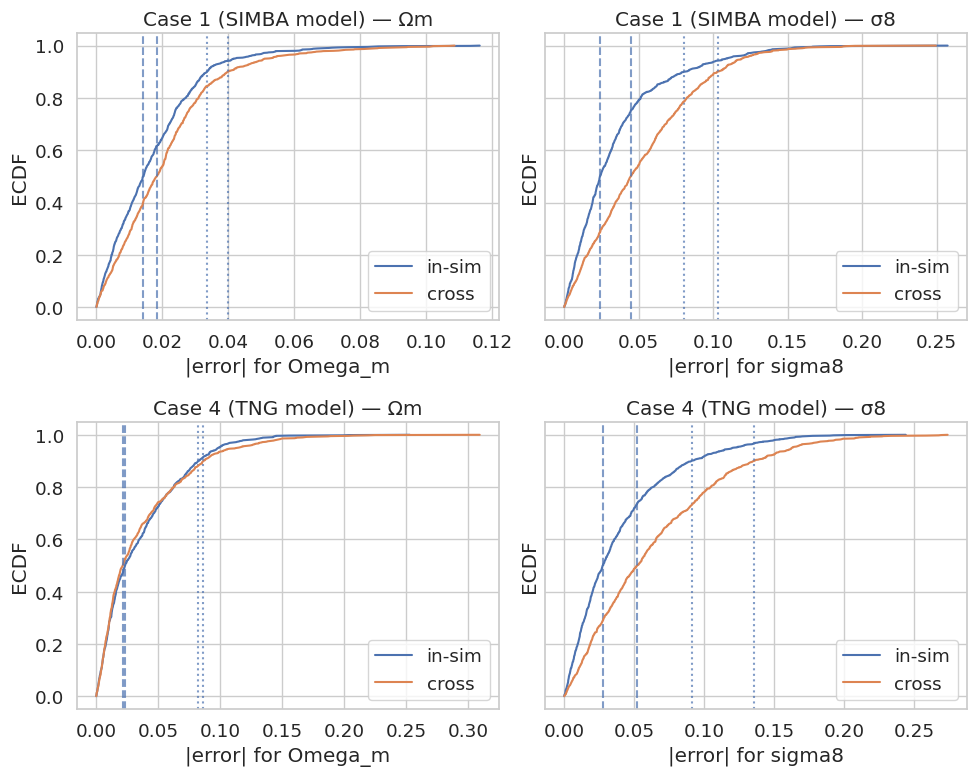

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_ecdf(y_true, y_pred, label, ax, pname):
    """ECDF of |error|"""
    errors = np.abs(y_pred - y_true)
    errors_sorted = np.sort(errors)
    ecdf = np.arange(1, len(errors_sorted)+1) / len(errors_sorted)
    ax.plot(errors_sorted, ecdf, label=label)
    
    # Median & P90 lines
    med = np.median(errors)
    p90 = np.quantile(errors, 0.9)
    ax.axvline(med, ls="--", alpha=0.7)
    ax.axvline(p90, ls=":", alpha=0.7)

def plot_all_ecdfs(insim_simba, cross_simba, insim_tng, cross_tng):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

    cases = [
        ("Case 1 (SIMBA model) — Ωm", insim_simba, cross_simba, "Omega_m", axes[0,0]),
        ("Case 1 (SIMBA model) — σ8", insim_simba, cross_simba, "sigma8", axes[0,1]),
        ("Case 4 (TNG model) — Ωm",   insim_tng,   cross_tng,   "Omega_m", axes[1,0]),
        ("Case 4 (TNG model) — σ8",   insim_tng,   cross_tng,   "sigma8",  axes[1,1]),
    ]

    for title, df_in, df_cross, pname, ax in cases:
        plot_ecdf(df_in[f"true_{pname}"],  df_in[f"pred_{pname}"],  "in-sim", ax, pname)
        plot_ecdf(df_cross[f"true_{pname}"], df_cross[f"pred_{pname}"], "cross", ax, pname)
        ax.set_title(title)
        ax.set_xlabel(f"|error| for {pname}")
        ax.set_ylabel("ECDF")
        ax.legend()

    plt.tight_layout()
    plt.savefig("./this.png", dpi=300, bbox_inches="tight")
    plt.show()

# Example usage
plot_all_ecdfs(insim_df_simba, cross_df_simba, insim_df_tng, cross_df_tng)


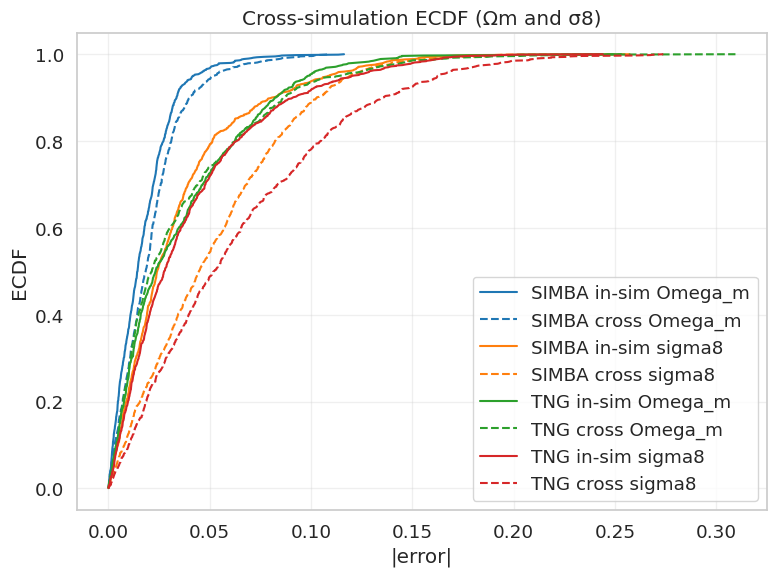

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_ecdf_single(y_true, y_pred):
    errors = np.abs(y_pred - y_true)
    errors_sorted = np.sort(errors)
    ecdf = np.arange(1, len(errors_sorted)+1) / len(errors_sorted)
    return errors_sorted, ecdf

def plot_all_in_one(insim_simba, cross_simba, insim_tng, cross_tng):
    plt.figure(figsize=(8,6))

    # Case 1 (SIMBA model)
    for pname, color in zip(["Omega_m", "sigma8"], ["tab:blue", "tab:orange"]):
        x, y = plot_ecdf_single(insim_simba[f"true_{pname}"], insim_simba[f"pred_{pname}"])
        plt.plot(x, y, ls="-", color=color, label=f"SIMBA in-sim {pname}")
        x, y = plot_ecdf_single(cross_simba[f"true_{pname}"], cross_simba[f"pred_{pname}"])
        plt.plot(x, y, ls="--", color=color, label=f"SIMBA cross {pname}")

    # Case 4 (TNG model)
    for pname, color in zip(["Omega_m", "sigma8"], ["tab:green", "tab:red"]):
        x, y = plot_ecdf_single(insim_tng[f"true_{pname}"], insim_tng[f"pred_{pname}"])
        plt.plot(x, y, ls="-", color=color, label=f"TNG in-sim {pname}")
        x, y = plot_ecdf_single(cross_tng[f"true_{pname}"], cross_tng[f"pred_{pname}"])
        plt.plot(x, y, ls="--", color=color, label=f"TNG cross {pname}")

    plt.xlabel("|error|")
    plt.ylabel("ECDF")
    plt.title("Cross-simulation ECDF (Ωm and σ8)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_all_in_one(insim_df_simba, cross_df_simba, insim_df_tng, cross_df_tng)


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ecdf_casewise(insim_df_simba, cross_df_simba, insim_df_tng, cross_df_tng):
    fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

    # Case 1: SIMBA model
    for pname, color in zip(["Omega_m", "sigma8"], ["blue", "orange"]):
        for label, df, ls in [("in-sim", insim_df_simba, "-"), ("cross", cross_df_simba, "--")]:
            errs = np.abs(df[f"pred_{pname}"].values - df[f"true_{pname}"].values)
            x = np.sort(errs)
            y = np.arange(1, len(x)+1) / len(x)
            axes[0].plot(x, y, ls=ls, color=color, label=f"{label} {pname}")
    axes[0].set_title("SIMBA → TNG")
    axes[0].set_xlabel("|error|")
    axes[0].set_ylabel("ECDF")
    axes[0].legend()

    # Case 2: TNG model
    for pname, color in zip(["Omega_m", "sigma8"], ["green", "red"]):
        for label, df, ls in [("in-sim", insim_df_tng, "-"), ("cross", cross_df_tng, "--")]:
            errs = np.abs(df[f"pred_{pname}"].values - df[f"true_{pname}"].values)
            x = np.sort(errs)
            y = np.arange(1, len(x)+1) / len(x)
            axes[1].plot(x, y, ls=ls, color=color, label=f"{label} {pname}")
    axes[1].set_title("TNG → SIMBA")
    axes[1].set_xlabel("|error|")
    axes[1].legend()

    plt.suptitle("Cross-simulation ECDF by Case")
    plt.tight_layout()
    plt.show()


In [24]:
def plot_ecdf_paramwise(insim_df_simba, cross_df_simba, insim_df_tng, cross_df_tng):
    fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

    # Parameter 1: Ωm
    for model, color, insim, cross in [
        ("SIMBA", "blue", insim_df_simba, cross_df_simba),
        ("TNG",   "green", insim_df_tng,   cross_df_tng),
    ]:
        for label, df, ls in [("in-sim", insim, "-"), ("cross", cross, "--")]:
            errs = np.abs(df["pred_Omega_m"].values - df["true_Omega_m"].values)
            x = np.sort(errs)
            y = np.arange(1, len(x)+1) / len(x)
            axes[0].plot(x, y, ls=ls, color=color, label=f"{model} {label}")
    axes[0].set_title("ECDF for Ωm")
    axes[0].set_xlabel("|error|")
    axes[0].set_ylabel("ECDF")
    axes[0].legend()

    # Parameter 2: σ8
    for model, color, insim, cross in [
        ("SIMBA", "orange", insim_df_simba, cross_df_simba),
        ("TNG",   "red", insim_df_tng,   cross_df_tng),
    ]:
        for label, df, ls in [("in-sim", insim, "-"), ("cross", cross, "--")]:
            errs = np.abs(df["pred_sigma8"].values - df["true_sigma8"].values)
            x = np.sort(errs)
            y = np.arange(1, len(x)+1) / len(x)
            axes[1].plot(x, y, ls=ls, color=color, label=f"{model} {label}")
    axes[1].set_title("ECDF for σ8")
    axes[1].set_xlabel("|error|")
    axes[1].legend()

    plt.suptitle("Cross-simulation ECDF by Parameter")
    plt.tight_layout()
    plt.show()


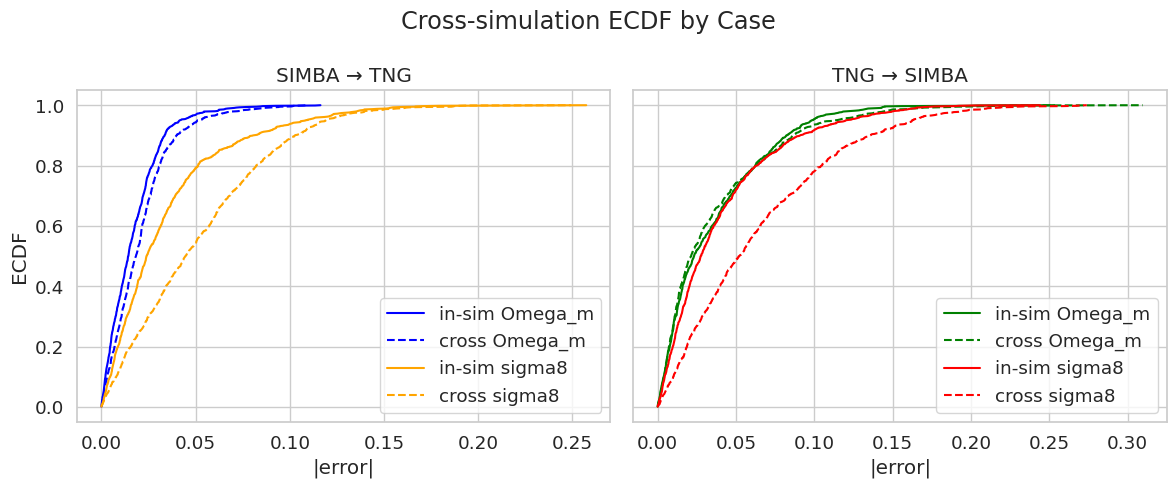

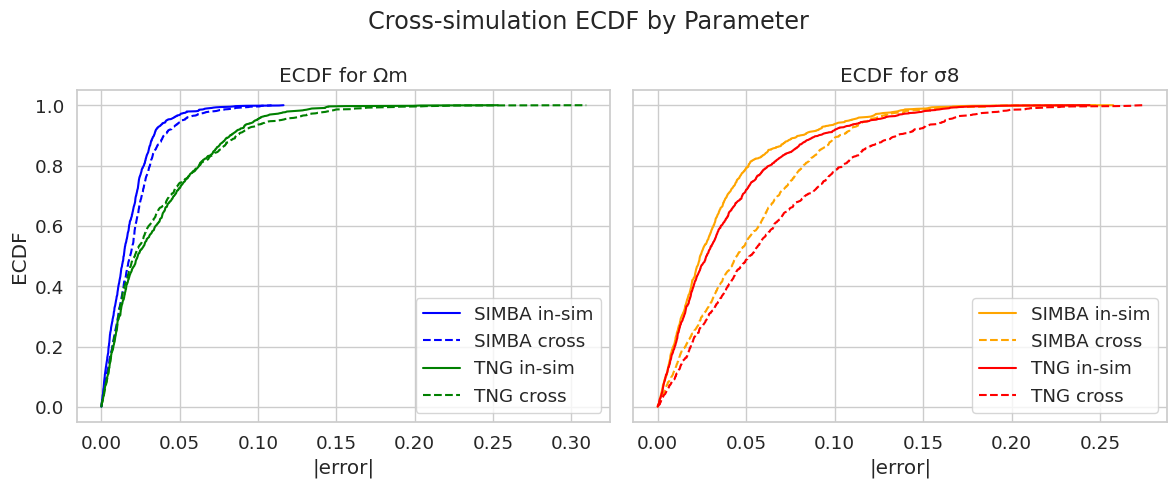

In [25]:
# ------------------------------------------
# Case별 ECDF
# ------------------------------------------
plot_ecdf_casewise(
    insim_df_simba, cross_df_simba,
    insim_df_tng, cross_df_tng
)

# ------------------------------------------
# Parameter별 ECDF
# ------------------------------------------
plot_ecdf_paramwise(
    insim_df_simba, cross_df_simba,
    insim_df_tng, cross_df_tng
)
